In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

In [200]:
df = pd.read_csv('marketing_campaign.csv',sep='\t')

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

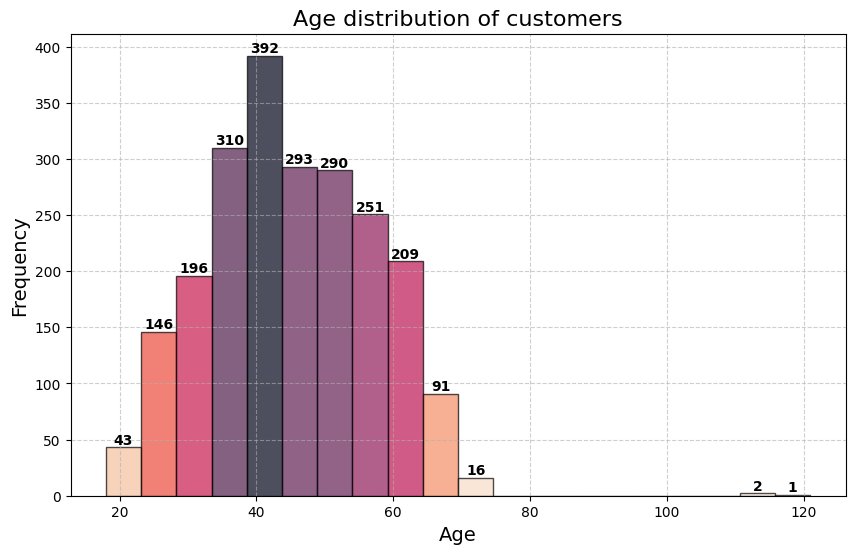

In [ ]:
df['Age'] = 2014 - df['Year_Birth']

plt.figure(figsize=(10, 6))

# Normalize color by the bar height
n, bins, patches = plt.hist(df['Age'], bins=20, color='blue', alpha=0.7, edgecolor='black')
for i in range(len(patches)):
    patches[i].set_facecolor(sns.color_palette("rocket_r", as_cmap=True)(n[i] / max(n)))
    if n[i] > 0:
        plt.text(patches[i].get_x() + patches[i].get_width() / 2, n[i], int(n[i]), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Age distribution of customers', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14) 
plt.grid(True, linestyle='--', alpha=0.6) 
plt.show()  

In [203]:
total_customers = len(df['Income'].dropna())
high_income_customers = len(df[df['Income'] > 100000])
percentage_high_income = (high_income_customers / total_customers) * 100

print(f"Percentage of customers with income supérior to 100,000: {percentage_high_income:.2f}%")

Percentage of customers with income supérior to 100,000: 0.59%


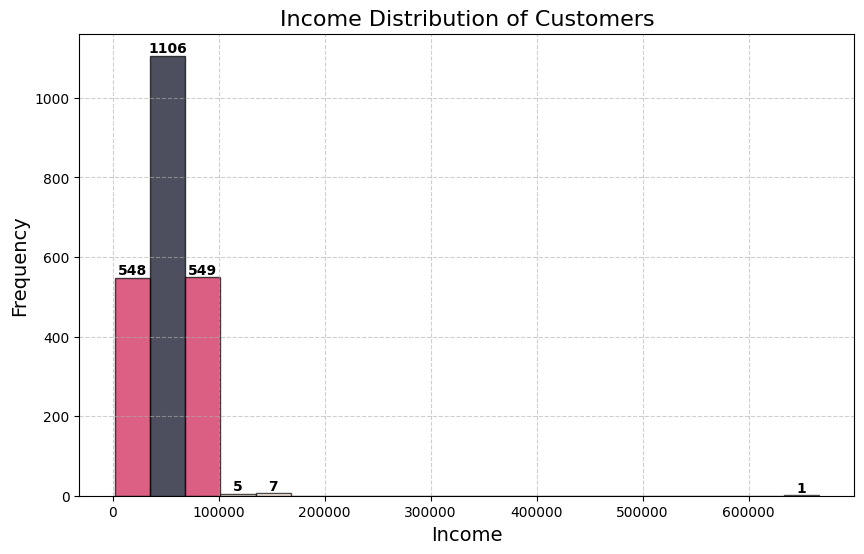

In [204]:
plt.figure(figsize=(10, 6))

# Drop missing income values
income = df['Income'].dropna()

# Plot histogram
n, bins, patches = plt.hist(income, bins=20, alpha=0.7, edgecolor='black')

# Normalize color by bar height
for i in range(len(patches)):
    patches[i].set_facecolor(
        sns.color_palette("rocket_r", as_cmap=True)(n[i] / max(n))
    )
    if n[i] > 0:
        plt.text(
            patches[i].get_x() + patches[i].get_width() / 2,
            n[i],
            int(n[i]),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

plt.title('Income Distribution of Customers', fontsize=16)
plt.xlabel('Income', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Spending Patterns on Products

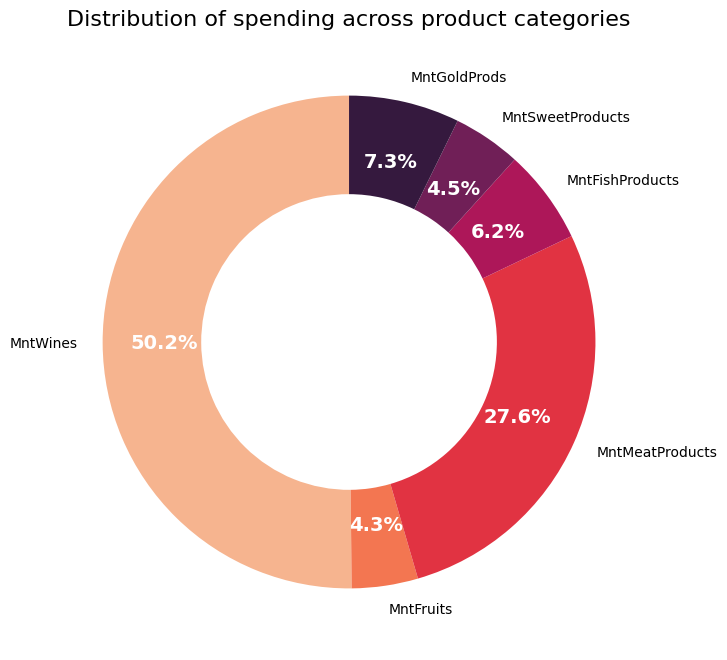

In [205]:
product_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
total_spend = df[product_columns].sum()


colors = sns.color_palette("rocket_r", len(product_columns))
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(total_spend, labels=product_columns, autopct='%1.1f%%', 
                                   startangle=90, colors=colors, wedgeprops=dict(width=0.4), pctdistance=0.75)
for autotext in autotexts:
    autotext.set_color('white')  # white for better contrast
    autotext.set_fontsize(14)    
    autotext.set_weight('bold')  

# Add title
plt.title('Distribution of spending across product categories', fontsize=16)

plt.show()

### Spending by marital status

Text(0.5, 0, 'Marital status')

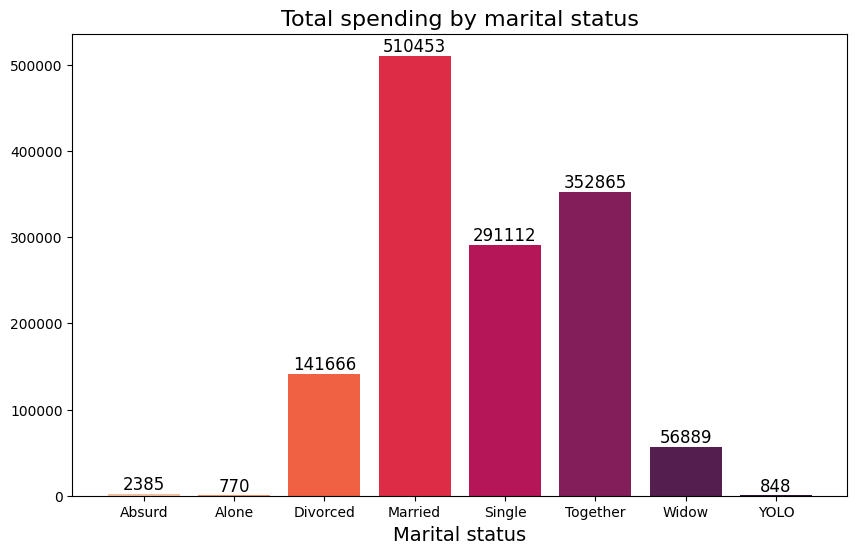

In [206]:
df['Total_Spend'] = df[product_columns].sum(axis=1)

spending_by_marital_status = df.groupby('Marital_Status')['Total_Spend'].sum()
norm = spending_by_marital_status / spending_by_marital_status.max()

plt.figure(figsize=(10, 6))
bars = plt.bar(spending_by_marital_status.index, spending_by_marital_status, 
               color=sns.color_palette("rocket_r", len(spending_by_marital_status)))

for bar, spend in zip(bars, spending_by_marital_status):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(spend)}', ha='center', va='bottom', fontsize=12)

plt.title('Total spending by marital status', fontsize=16)
plt.xlabel('Marital status', fontsize=14)

### Preprocessing encodeing and feature engingeering

In [207]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [208]:
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

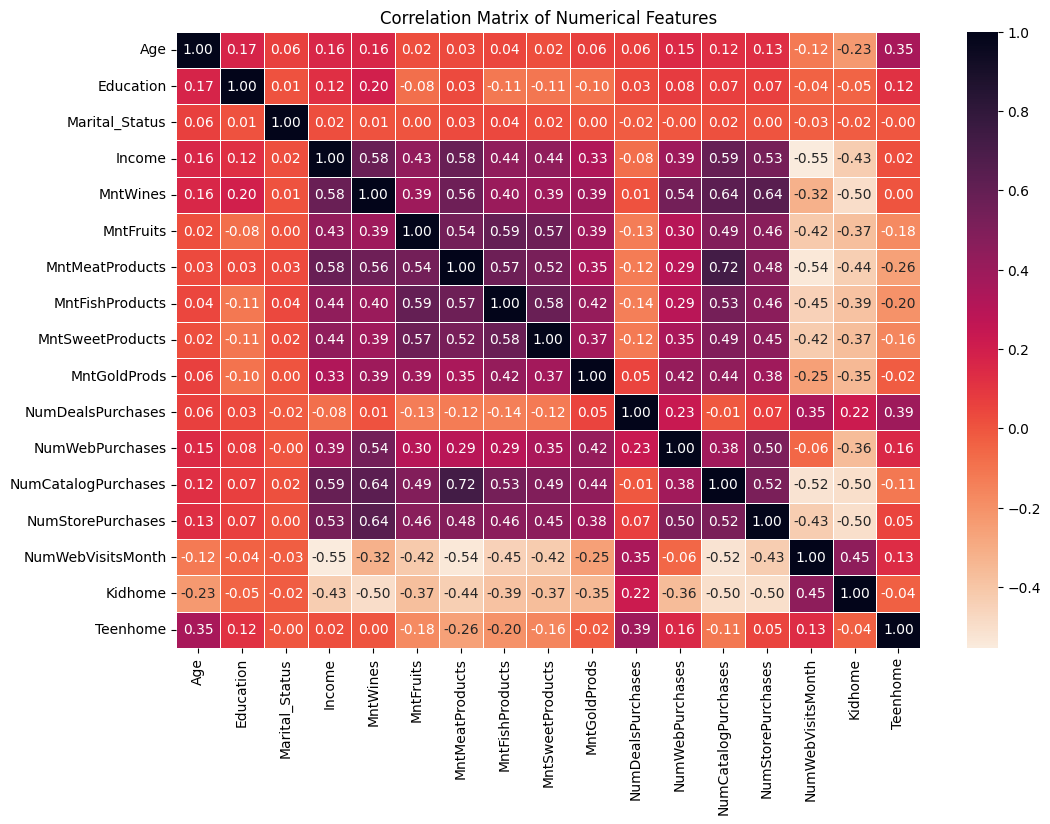

In [209]:
numerical_cols = ['Age', 'Education', 'Marital_Status', 'Income', 'MntWines', 
                  'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
                  'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 
                  'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 
                  'NumWebVisitsMonth','Kidhome', 'Teenhome']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='rocket_r', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [210]:
df['Family_Size'] = df['Kidhome'] + df['Teenhome']

In [211]:
df['Avg_Spend_Per_Purchase'] = df['Total_Spend'] / (df['NumDealsPurchases'] + df['NumWebPurchases'] + 
                                                    df['NumCatalogPurchases'] + df['NumStorePurchases'])

In [212]:
# df['Wine_Ratio'] = df['MntWines'] / df['Total_Spend']
# df['Meat_Ratio'] = df['MntMeatProducts'] / df['Total_Spend']
# df['Fruit_Ratio'] = df['MntFruits'] / df['Total_Spend']

In [213]:
df['Total_Accepted_Campaigns'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + 
                                  df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5'])

In [214]:
df =df.dropna()

<Figure size 800x600 with 0 Axes>

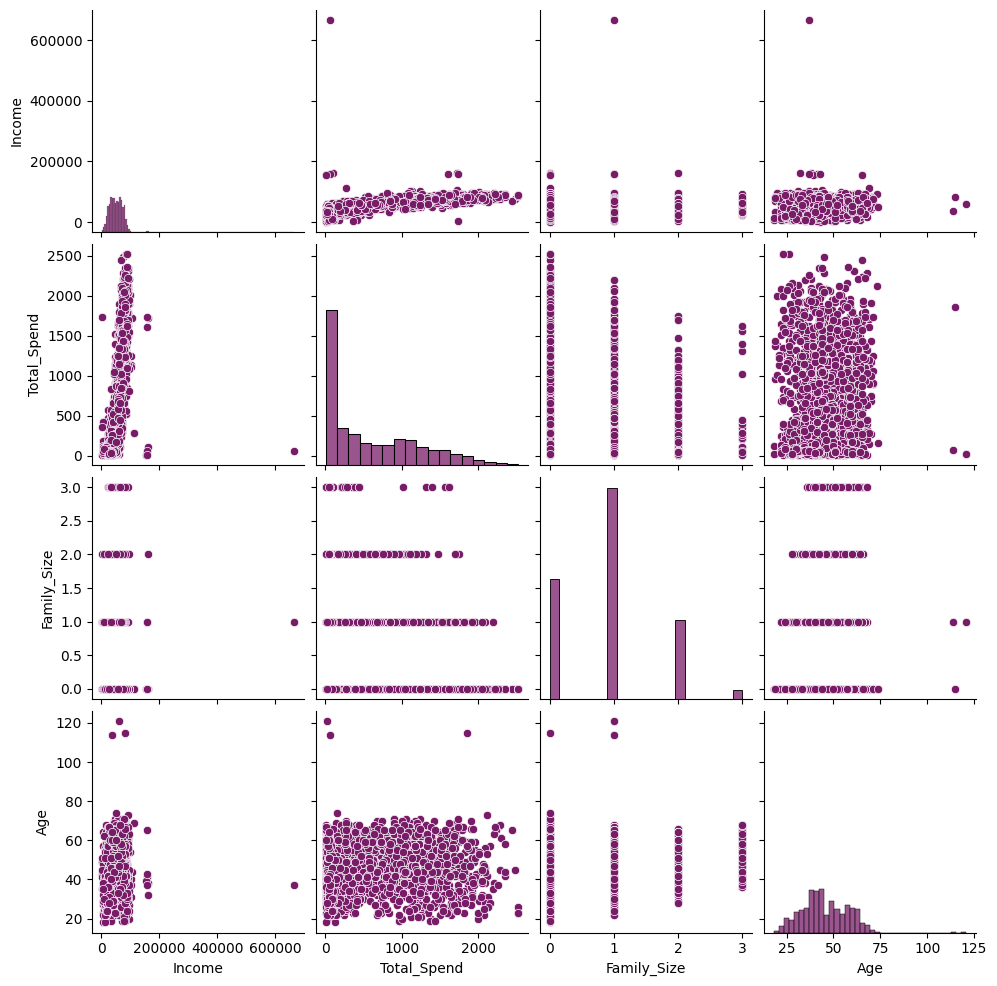

In [215]:
plt.figure(figsize=(8, 6))
sns.pairplot(df[['Income', 'Total_Spend', 'Family_Size', 'Age']],
             plot_kws={'color': '#781C68'},
             diag_kws={'color': '#781C68', 'fill': True}) 
plt.show()

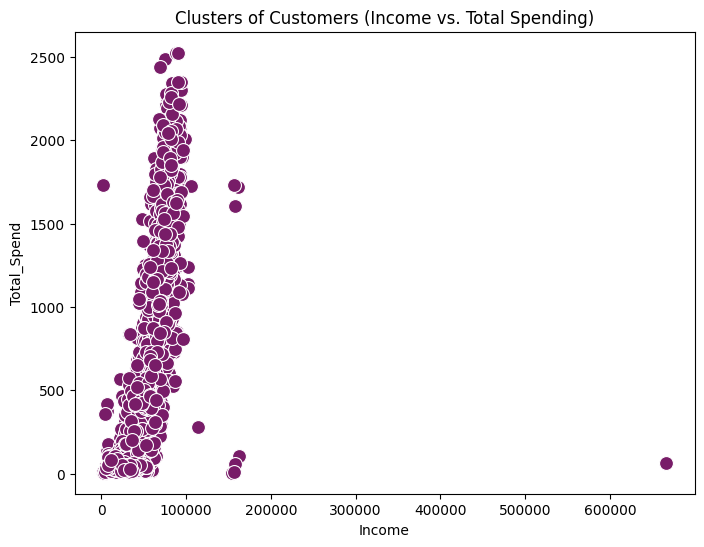

In [216]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Income', y='Total_Spend', data=df, s=100, color='#781C68') 
plt.title('Clusters of Customers (Income vs. Total Spending)')
plt.show()

In [217]:
# Remove extreme outliers
df = df[df['Income'] < 200000]

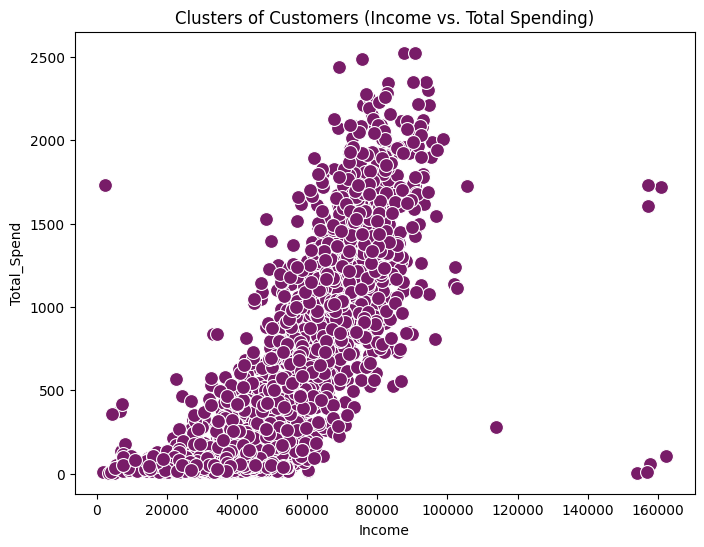

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Income', y='Total_Spend', data=df, s=100, color='#781C68') 
plt.title('Clusters of Customers (Income vs. Total Spending)')
plt.show()

In [219]:
outlier_percentages = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    percentage = len(outliers) / len(df) * 100
    outlier_percentages[col] = round(percentage, 2)

outlier_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['Outlier %'])
outlier_df = outlier_df.sort_values(by="Outlier %", ascending=False)
outlier_df

,Outlier %
MntSweetProducts,11.11
MntFruits,11.11
MntFishProducts,10.02
MntGoldProds,9.26
Education,9.03
MntMeatProducts,7.86
NumDealsPurchases,3.79
MntWines,1.58
NumCatalogPurchases,1.04
NumWebVisitsMonth,0.36


### Feature for clustering

In [220]:
features = ['Income', 'Total_Spend', 'Age', 'Family_Size']

# Scaling the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

# Convert the scaled data back to a DataFrame (optional, for easy manipulation)
scaled_df = pd.DataFrame(scaled_features, columns=features)

Elbow Method for Determining Optimal Clusters

The Elbow Method is a technique used to determine the optimal number of clusters (K) for K-Means clustering. The goal is to choose a K value that minimizes the sum of squared distances between each point and its assigned cluster center, known as the Sum of Squared Errors (SSE).

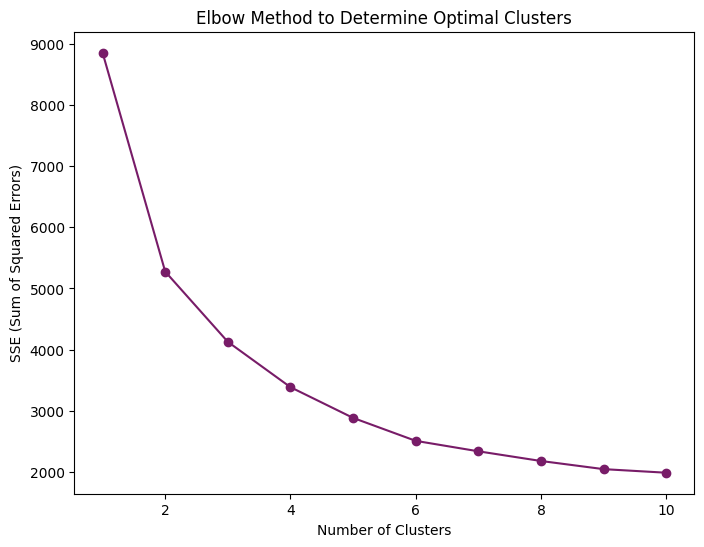

In [221]:
# Elbow Method to find the optimal number of clusters
sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

# plot the Elbow graph
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o', color='#781C68')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method to Determine Optimal Clusters')
plt.show()

Elbow Method suggests 3 or 4 clusters

## K-mean

In [222]:
optimal_clusters = 3

# Running K-Means with the chosen number of (optimal) clusters
kmeans = KMeans(n_clusters=optimal_clusters,n_init=20, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)

In [223]:
# Scatter plot to visualize the clusters based on Income and Total Spend
import plotly.express as px

fig = px.scatter(
    df,
    x='Income',
    y='Total_Spend',
    color='Cluster',
    title='Clusters of Customers (Income vs. Total Spending)',
    labels={
        'Income': 'Income',
        'Total_Spend': 'Total Spending',
        'Cluster': 'Cluster'
    },
    opacity=0.8
)

fig.update_traces(marker=dict(size=8))
fig.update_layout(
    width=800,
    height=600,
    legend_title_text='Clusters'
)

fig.show()


In [224]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spend',
    z='Age',
    color='Cluster',
    title='3D Scatter Plot of Clusters (Income, Total Spend, Age)',
    labels={
        'Income': 'Income',
        'Total_Spend': 'Total Spend',
        'Age': 'Age',
        'Cluster': 'Cluster'
    },
    opacity=0.8
)

fig.update_traces(marker=dict(size=6))
fig.update_layout(
    legend_title_text='Clusters',
    width=900,
    height=700
)

fig.show()


In [241]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1) Select features from your df (edit if your column names differ)
features = ['Income', 'Total_Spend', 'Age']
X = df[features].dropna().copy()

# 2) Scale features (recommended for KMeans)
X_scaled = StandardScaler().fit_transform(X)

# 3) Silhouette evaluation for k=2..9
sc_av = []
ks = list(range(2, 10))

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sc_av.append(silhouette_score(X_scaled, labels))

# 4) Build results table
sc_df = pd.DataFrame({
    'k': ks,
    'Silhouette Coefficient': sc_av
})

# 5) Best k
best_k = sc_df.loc[sc_df['Silhouette Coefficient'].idxmax(), 'k']

# 6) Plot
fig6 = px.line(
    sc_df,
    x='k',
    y='Silhouette Coefficient',
    markers=True,
    title='Silhouette Coefficient vs K'
)

fig6.add_trace(
    go.Scatter(
        x=[best_k, best_k],
        y=[min(sc_av), max(sc_av)],
        mode='lines',
        line=dict(dash='dash'),
        name=f'Best K = {best_k}'
    )
)

fig6.update_layout(width=600, height=400)
fig6.show()

print("Best k by silhouette:", int(best_k))


Best k by silhouette: 2


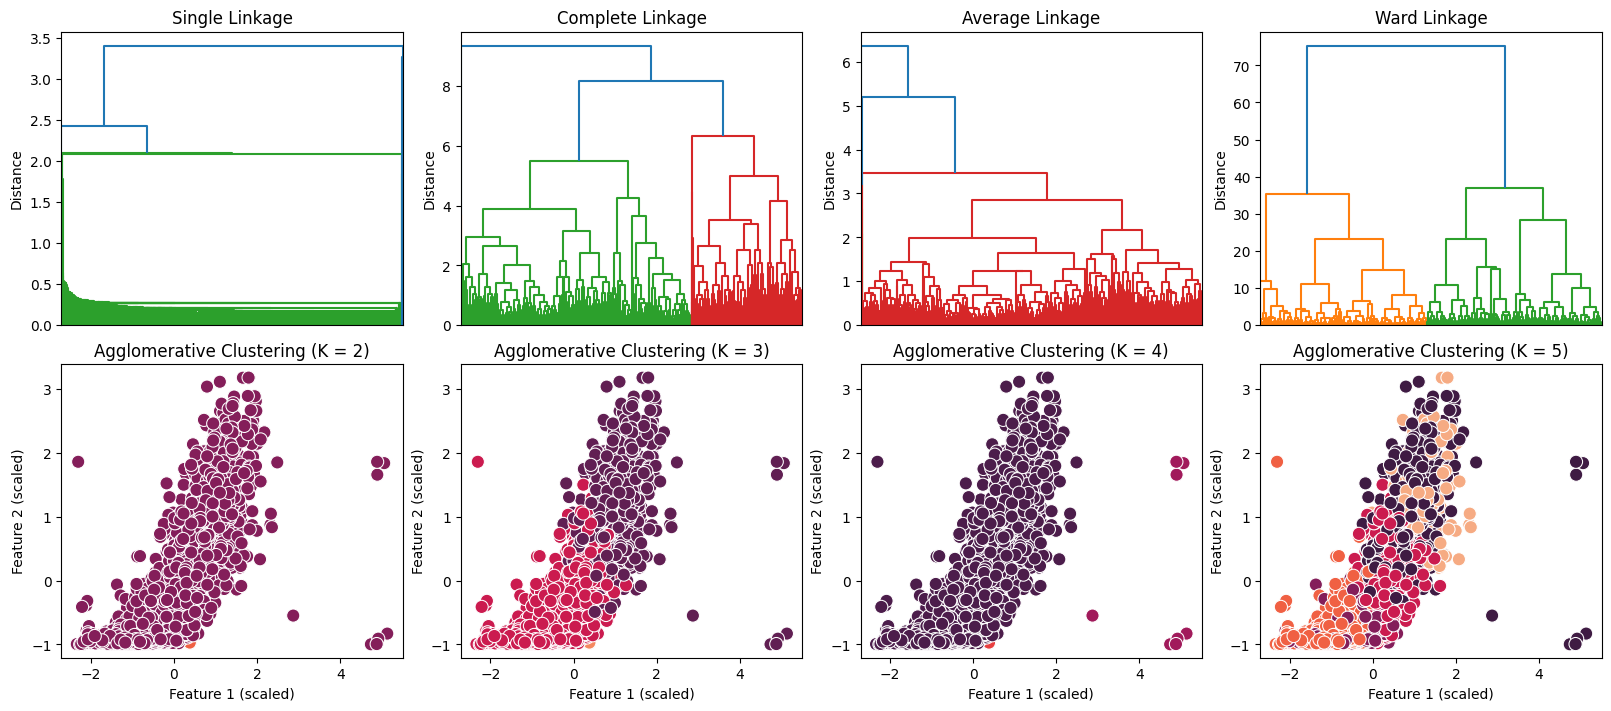

In [242]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# --- Prepare X from df1 (works for DataFrame or numpy array) ---
# X = df.values if hasattr(df1, "values") else np.array(df1)
features = ['Income', 'Total_Spend', 'Age']
X = df[features].dropna().copy()

# (Recommended) scale features for hierarchical clustering
X_scaled = StandardScaler().fit_transform(X)

# Linkage methods + number of clusters you want to visualize
configs = [
    ("single",   2),
    ("complete", 3),
    ("average",  4),
    ("ward",     5),
]

fig, axs = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)

for i, (method, k) in enumerate(configs):

    # 1) Dendrogram (SciPy)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, ax=axs[0, i], no_labels=True, color_threshold=None)
    axs[0, i].set_title(f"{method.capitalize()} Linkage")
    axs[0, i].set_xticks([])
    axs[0, i].set_ylabel("Distance")

    # 2) Agglomerative clustering (Bottom-up)
    if method == "ward":
        model = AgglomerativeClustering(n_clusters=k, linkage="ward", metric="euclidean")
    else:
        model = AgglomerativeClustering(n_clusters=k, linkage=method, metric="euclidean")

    labels = model.fit_predict(X_scaled)

    # Scatter plot using first 2 features
    sns.scatterplot(
        x=X_scaled[:, 0],
        y=X_scaled[:, 1],
        hue=labels.astype(str),
        palette="rocket",
        s=90,
        ax=axs[1, i],
        legend=False
    )
    axs[1, i].set_title(f"Agglomerative Clustering (K = {k})")
    axs[1, i].set_xlabel("Feature 1 (scaled)")
    axs[1, i].set_ylabel("Feature 2 (scaled)")

plt.show()


- Average Silhouette Across Different K

In [227]:

results = []

for k in range(2, 8):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)

    results.append({
        'K': k,
        'Average Silhouette': silhouette_score(X_scaled, labels)
    })

silhouette_df = pd.DataFrame(results)
silhouette_df


,K,Average Silhouette
0,2,0.377421
1,3,0.312138
2,4,0.294776
3,5,0.286401
4,6,0.258445
5,7,0.259020


# PCA

In [228]:
from sklearn.preprocessing import StandardScaler

features = ['Income', 'Total_Spend', 'Age']
X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [229]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Number of PCA components:", pca.n_components_)
print("Explained variance ratio:", np.sum(pca.explained_variance_ratio_))

Number of PCA components: 3
Explained variance ratio: 1.0


- K-Means on PCA Space

In [230]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    sil_scores.append({
        'K': k,
        'Silhouette (PCA + KMeans)': silhouette_score(X_pca, labels)
    })

import pandas as pd
sil_df = pd.DataFrame(sil_scores)
sil_df


,K,Silhouette (PCA + KMeans)
0,2,0.420987
1,3,0.368691
2,4,0.359892
3,5,0.356112
4,6,0.313240
5,7,0.303010


In [ ]:
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import pandas as pd 
import numpy as np  

# Select features
X = df[['Income', 'Total_Spend', 'Age']].dropna()

# Scale
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=X.index
)

# Explained variance
explained_var = pca.explained_variance_ratio_
explained_var, explained_var.sum()


(array([0.61660544, 0.3158417 ]), 0.9324471422416261)

In [243]:
import plotly.express as px

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    title='PCA Projection of Customers (No Clustering)',
    opacity=0.7
)
fig.show()


# PCA

In [244]:
df_pca = df[numerical_cols].dropna()
print("Number of original numerical features:", df_pca.shape[1])


Number of original numerical features: 17


In [246]:
df_pca.columns

Index(['Age', 'Education', 'Marital_Status', 'Income', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Kidhome', 'Teenhome'],
      dtype='object')

In [234]:
# standardize 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)


In [235]:
pca = PCA(n_components=0.95)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Reduced dimensions:", pca.n_components_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Reduced dimensions: 14
Total explained variance: 0.9625813520086547


In [236]:
explained_df = pd.DataFrame({
    'Principal Component': range(1, pca.n_components_ + 1),
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

explained_df


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,1,0.369052,0.369052
1,2,0.118623,0.487675
2,3,0.079767,0.567442
3,4,0.061220,0.628662
4,5,0.057329,0.685991
5,6,0.044816,0.730808
6,7,0.039302,0.770110
7,8,0.037801,0.807911
8,9,0.034294,0.842205
9,10,0.026847,0.869052


In [237]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=numerical_cols,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

loadings.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
Age,0.067441,0.349265,-0.374630,0.392674,0.275529,0.108432,0.420234,0.189028,0.442675,-0.248291,-0.041515,0.067474,-0.119993,-0.004592
Education,0.019426,0.252987,-0.471467,-0.470370,-0.314539,0.063814,0.453413,-0.046775,-0.370610,0.127415,-0.043644,0.152176,0.005641,0.024726
Marital_Status,0.010315,-0.000676,-0.116682,0.606479,-0.778046,-0.037351,-0.072886,-0.033179,-0.062093,0.002570,-0.002532,-0.024172,-0.023517,-0.002838
Income,0.342322,0.073543,-0.161487,-0.072499,0.002405,0.141048,-0.195135,-0.015297,-0.039938,-0.150117,0.254790,-0.209917,0.058841,0.085014
MntWines,0.302250,0.195817,-0.032192,-0.230050,-0.166257,-0.207290,-0.108784,0.007604,0.222640,-0.148203,0.043912,-0.208467,0.075190,-0.517755


In [ ]:
import plotly.express as px

pca_2d = pd.DataFrame(
    X_pca[:, :2],
    columns=['PC1', 'PC2'],
    index=df_pca.index
)

fig = px.scatter(
    pca_2d,
    x='PC1',
    y='PC2',
    title='PCA Projection Using All Numerical Features',
    opacity=0.7
)
fig.show()


In [239]:
import numpy as np
import pandas as pd

# PCA loadings scaled to correlations
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

Corr_matrix = pd.DataFrame(
    loadings[:, :2],   # PC1, PC2
    index=numerical_cols,
    columns=['PC1', 'PC2']
)


In [240]:
import plotly.graph_objects as go

fig_cir = go.Figure()

# Unit circle
theta = np.linspace(0, 2*np.pi, 200)
fig_cir.add_trace(go.Scatter(
    x=np.cos(theta),
    y=np.sin(theta),
    mode='lines',
    name='Unit Circle',
    line=dict(color='black', dash='dash')
))

# Axes
fig_cir.add_trace(go.Scatter(
    x=[-1, 1], y=[0, 0],
    mode='lines',
    line=dict(color='gray', dash='dash'),
    showlegend=False
))
fig_cir.add_trace(go.Scatter(
    x=[0, 0], y=[-1, 1],
    mode='lines',
    line=dict(color='gray', dash='dash'),
    showlegend=False
))

# Text positions
loc = ['top right','top left','bottom right','bottom left'] * 10

# Variable vectors
for i, feature in enumerate(Corr_matrix.index):
    fig_cir.add_trace(go.Scatter(
        x=[0, Corr_matrix.iloc[i, 0]],
        y=[0, Corr_matrix.iloc[i, 1]],
        mode='lines+text',
        text=[None, feature],
        textposition=loc[i],
        line=dict(width=2),
        showlegend=False
    ))

# Layout
fig_cir.update_layout(
    title='PCA Correlation Circle',
    xaxis=dict(
        title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        range=[-1.2, 1.2],
        zeroline=False
    ),
    yaxis=dict(
        title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        range=[-1.2, 1.2],
        zeroline=False
    ),
    width=500,
    height=500
)

fig_cir.show()


# PCA3

In [247]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)
df['kids'] = df['Kidhome'] + df['Teenhome']

df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)
 
df['Deal_Intensity'] = df['NumDealsPurchases'] / (df['Total_Purchases'] + 1)


In [248]:
pca_features = [
    'Income',
    'Age',
    'kids',
    'Total_Spending',
    'Total_Purchases',
    'NumWebVisitsMonth',
    'Deal_Intensity'
]

df_pca = df[pca_features].dropna()


In [252]:

X_scaled = StandardScaler().fit_transform(df_pca)


pca = PCA()
X_pca = pca.fit_transform(X_scaled)

import numpy as np
np.cumsum(pca.explained_variance_ratio_)



array([0.48988726, 0.64582268, 0.78086434, 0.87331407, 0.95247953,
       0.97977861, 1.        ])

In [250]:
pca = PCA(n_components=0.75)
X_pca = pca.fit_transform(X_scaled)


In [ ]:
import pandas as pd 
import numpy as np 
import plotly.express as px  
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 

# --- Standardize ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- PCA scores DataFrame ---
pca_scores = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

# --- Plot ---
fig = px.scatter(
    pca_scores,
    x='PC1',
    y='PC2',
    opacity=0.6
)

fig.update_layout(
    title=f"PCA Score Plot (PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
          f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%)",
    xaxis_title="PC1",
    yaxis_title="PC2",
    width=650,
    height=500
)

fig.show()


In [257]:
import plotly.graph_objects as go

# --- PCA loadings ---
loadings = pca.components_.T
feature_names = df_pca.columns

# --- Scale factor for arrows (adjust if needed) ---
arrow_scale = 3

fig = go.Figure()

# --- Scatter: PCA scores ---
fig.add_trace(
    go.Scatter(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        mode='markers',
        marker=dict(size=6, opacity=0.5),
        name='Customers'
    )
)

# --- Arrows: PCA loadings ---
for i, feature in enumerate(feature_names):
    fig.add_trace(
        go.Scatter(
            x=[0, loadings[i, 0] * arrow_scale],
            y=[0, loadings[i, 1] * arrow_scale],
            mode='lines+text',
            line=dict(color='red'),
            text=[None, feature],
            textposition='top center',
            name=feature
        )
    )

fig.update_layout(
    title="PCA Biplot (Scores and Variable Loadings)",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
    width=700,
    height=550,
    showlegend=False
)

# Axes lines
fig.add_hline(y=0, line_width=1, line_color="gray")
fig.add_vline(x=0, line_width=1, line_color="gray")

fig.show()


In [259]:
# Eigenvalues
eigvals = pca.explained_variance_

# Correlations (circle coordinates)
corr = pca.components_.T * np.sqrt(eigvals)

corr_df = pd.DataFrame(
    corr,
    columns=['PC1', 'PC2'],
    index=df_pca.columns
)


fig = go.Figure()

# --- Unit circle ---
theta = np.linspace(0, 2*np.pi, 300)
fig.add_trace(
    go.Scatter(
        x=np.cos(theta),
        y=np.sin(theta),
        mode='lines',
        line=dict(color='black'),
        name='Unit circle'
    )
)

# --- Axes ---
fig.add_hline(y=0, line_width=1, line_color="gray")
fig.add_vline(x=0, line_width=1, line_color="gray")

# --- Variable arrows ---
for var in corr_df.index:
    fig.add_trace(
        go.Scatter(
            x=[0, corr_df.loc[var, 'PC1']],
            y=[0, corr_df.loc[var, 'PC2']],
            mode='lines+text',
            line=dict(color='red'),
            text=[None, var],
            textposition='top center',
            name=var
        )
    )

fig.update_layout(
    title=(
        f"PCA Correlation Circle<br>"
        f"PC1 = {pca.explained_variance_ratio_[0]*100:.1f}%, "
        f"PC2 = {pca.explained_variance_ratio_[1]*100:.1f}%"
    ),
    xaxis_title='PC1',
    yaxis_title='PC2',
    width=650,
    height=650,
    showlegend=False,
    xaxis=dict(scaleanchor="y", scaleratio=1),
    yaxis=dict(scaleanchor="x", scaleratio=1)
)

fig.show()


Interpretation of the PCA Correlation Circle

- Explained variance:
    The first two principal components explain 64.6% of the total variance (PC1 = 49.0%, PC2 = 15.6%), indicating that they capture a substantial portion of the information in the data.

- PC1 – Economic activity / customer value dimension:
    Total_Spending, Total_Purchases, and Income point strongly in the negative direction of PC1 and are closely aligned, showing they are positively correlated with each other.
    This suggests that PC1 represents overall customer value or purchasing intensity.

- PC2 – Demographic & engagement contrast:
    Age loads strongly on PC2, while kids, Deal_Intensity, and NumWebVisitsMonth also contribute positively.
    This indicates that PC2 contrasts demographic and household characteristics with engagement and price-sensitive behavior.

- Relationship between variables:

    - Variables pointing in the same direction (e.g., Total_Spending and Total_Purchases) are positively correlated.

    - Variables pointing in different directions (e.g., Age vs Total_Spending) show weaker or opposing relationships.

    - Variables near the unit circle are well represented by PC1 and PC2.

In [261]:
loadings = (pca.components_.T) * (pca.explained_variance_) ** (0.5)


# Correlation between variables and PCs
corr_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

contr_corr = pd.DataFrame(
    corr_loadings,
    index=df_pca.columns,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])]
)

# Show PC1 & PC2 (absolute values)
contr_corr.iloc[:, :2].abs().round(4)


,PC1,PC2
Income,0.8931,0.1541
Age,0.1932,0.8694
kids,0.5977,0.4676
Total_Spending,0.8974,0.0284
Total_Purchases,0.8494,0.1337
NumWebVisitsMonth,0.7428,0.0814
Deal_Intensity,0.3999,0.2618


### PC1 – Overall customer value / purchasing power

- Income (0.893), Total_Spending (0.897), and Total_Purchases (0.849) show very strong loadings on PC1.

-  NumWebVisitsMonth (0.743) also contributes substantially, indicating engagement accompanies higher purchasing activity.

-  kids (0.598) has a moderate association, suggesting household size plays a secondary role in overall spending.

**Interpretation:**
PC1 primarily represents overall customer value or purchasing intensity, combining income level, spending amount, purchase frequency, and engagement.

### PC2 – Demographic & household structure dimension

- Age (0.869) is the dominant contributor to PC2.

- kids (0.468) also loads moderately, indicating household composition is related to this axis.

- Deal_Intensity (0.262) contributes modestly, suggesting some association with price-sensitive behavior.

**Interpretation:**
PC2 captures a demographic and household structure dimension, contrasting age and family characteristics rather than pure spending power.

In [262]:
# contribution (%) per PC
# Squared loadings
sq_loadings = pca.components_.T ** 2

# Contribution in %
contr_pct = sq_loadings / sq_loadings.sum(axis=0) * 100

contr_pct = pd.DataFrame(
    contr_pct,
    index=df_pca.columns,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])]
)

# Show PC1 & PC2 contributions
contr_pct.iloc[:, :2].round(2)


,PC1,PC2
Income,23.25,2.17
Age,1.09,69.21
kids,10.41,20.02
Total_Spending,23.48,0.07
Total_Purchases,21.03,1.64
NumWebVisitsMonth,16.08,0.61
Deal_Intensity,4.66,6.27


Each column (PC) sums to 100% 